# 02 — Main results

The pre-registered comparison: every fee policy against a same-trace static
baseline, over 72 windows per pair (24 per volatility tercile), three gas
scenarios and two address modes.

**Needs:** `results/summary.csv` from `uv run python run_matrix.py`.

**This is the arbitrage-only experiment**, and it is frozen. The third
experiment -- the same comparison under a two-flow model with uninformed users
-- is `07-uu-main-results.ipynb`, and it reads `results-uu/`. Neither replaces
the other; see
`docs/superpowers/specs/2026-08-09-uu-matrix-preregistration.md`.

**The claim boundary.** The analysis plan is fixed in §12.1 of the design spec
and was written _before any cell ran_. Do not edit it now that numbers exist —
choosing a metric after seeing the data is what pre-registration prevents. And
nothing here licenses "dynamic beats static" as a general claim: one year, three
pairs, arbitrage-only flow.


In [1]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT))

from experiments.aggregate import by_regime, paired_against_baseline
from experiments.figures import frontier, gas_breakeven, net_result_by_regime
from experiments.stats import analyse

FIGURES = ROOT / "paper" / "Image"
FIGURES.mkdir(parents=True, exist_ok=True)

frame = pd.read_csv(ROOT / "results" / "summary.csv")
print(f"{len(frame)} cells")
frame.head(3)

15552 cells


,policy,hook,fee_pips,pair,window_start_ms,regime,volatility,gas_price_wei,address_mode,fee_income,...,hodl_value,il,net_result,arb_profit,gas_cost,retained_volume,trade_count,conservation_error_token0,conservation_error_token1,error
0,BAHook,BAHook,0,ETH/SHIB,1704067200000,low,0.031161,5000000000,persistent,258.791429,...,2.062487e+07,6.412318,252.379111,-252.379111,17.733829,90030.727732,17,-1.196965e-16,0.0,NaN
1,BAHook,BAHook,0,ETH/SHIB,1704067200000,low,0.031161,20000000000,persistent,236.132336,...,2.062486e+07,-3.316289,239.448626,-239.448626,40.899059,85748.864684,9,-2.393060e-16,0.0,NaN
2,BAHook,BAHook,0,ETH/SHIB,1704067200000,low,0.031161,80000000000,persistent,222.671225,...,2.062486e+07,0.301384,222.369841,-222.369841,98.329761,79197.920563,5,0.000000e+00,0.0,NaN


## Health checks first

The conservation check compares pool state against trader flow from two
independent sources. It is not a development aid: it caught a silent int64
overflow in a pandas sum that would have corrupted every figure below without
anything failing.


In [2]:
failed = int(frame["error"].notna().sum()) if "error" in frame else 0
worst = (
    frame[["conservation_error_token0", "conservation_error_token1"]].abs().max().max()
)
zero_trade = frame[frame["trade_count"] == 0].groupby("pair").size()

print(f"errors: {failed}")
print(f"worst conservation error: {worst:.2e}")
assert failed == 0 and worst < 1e-6, "do not read the figures below until this passes"
print("\nzero-trade cells by pair (a finding, not a failure):")
print(zero_trade.to_string())

errors: 0
worst conservation error: 5.65e-16

zero-trade cells by pair (a finding, not a failure):
pair
ETH/SHIB      114
ETH/USDC       32
USDC/USDT    5108


`USDC/USDT` held too tight in 2024 for arbitrage to clear its gas. Combined with
its degenerate tercile cuts (notebook 01), the pair tells us where dynamic fees
do _not_ apply.


In [3]:
by_regime(frame).round(2)

,policy,regime,gas_price_wei,net_result_mean,net_result_sem,retained_volume_mean,fee_income_mean,il_mean,gas_cost_mean,trade_count_mean,n
0,ABHook,high,5000000000,-5971.03,2223.39,1316972.28,3985.45,9956.48,152.49,111.61,144
1,ABHook,high,20000000000,-6221.37,2253.12,1247551.46,3777.05,9998.42,414.30,75.86,144
2,ABHook,high,80000000000,-6704.41,2285.39,1112236.85,3370.18,10074.59,966.48,44.08,144
3,ABHook,low,5000000000,44.89,81.35,173811.29,522.98,478.10,33.93,27.17,144
4,ABHook,low,20000000000,-8.07,80.83,156076.49,469.64,477.71,76.60,15.22,144
...,...,...,...,...,...,...,...,...,...,...,...
103,VolatilityHook,low,20000000000,-219.09,82.22,413491.96,229.84,448.93,258.25,37.21,144
104,VolatilityHook,low,80000000000,-315.74,85.59,265892.14,156.73,472.47,379.12,13.32,144
105,VolatilityHook,mid,5000000000,-94.83,89.28,1028804.83,556.93,651.76,242.04,142.93,144
106,VolatilityHook,mid,20000000000,-236.50,91.64,773168.27,432.22,668.71,451.06,66.31,144


Every net result is negative: under arbitrage-only flow the LP loses against
HODL, whatever the fee policy. The comparison worth making is therefore between
policies at equal retained volume, not against zero.


## The pre-registered analysis

Wilcoxon signed-rank per comparison — the window P&L is heavy-tailed, so a
t-test would be reading its own assumptions — then Benjamini–Hochberg across the
whole family at `q = 0.05`. An effect size accompanies every flag: "significant"
answers whether an effect exists, not whether it matters.


In [4]:
paired = paired_against_baseline(frame)
result = analyse(paired)
result.to_csv(ROOT / "results" / "analysis.csv", index=False)

# The address axis is a control, and for every policy but MEVChargeHook the
# two modes give bit-identical results. Counting both inflates the family:
# quote the distinct comparisons. Benjamini-Hochberg is invariant to exact
# duplication, so the verdicts themselves are unaffected -- only the count.
distinct = result.drop_duplicates(
    subset=["policy", "pair", "regime", "gas_price_wei", "p"]
)
print(f"{len(result)} rows, {len(distinct)} distinct comparisons")
print(f"{int(distinct['significant_fdr'].sum())} significant after BH at q = 0.05")
result.head(20).round(4)

594 rows, 297 distinct comparisons
116 significant after BH at q = 0.05


,policy,pair,regime,gas_price_wei,address_mode,p,median,win_rate,n,n_effective,significant_fdr
0,MyHook@500,ETH/SHIB,high,5000000000,fresh,0.0,-2923.8440,0.0,24,24,True
1,VolatilityHook,ETH/SHIB,high,80000000000,fresh,0.0,-2754.5117,0.0,24,24,True
2,VolatilityHook,ETH/SHIB,high,80000000000,persistent,0.0,-2754.5117,0.0,24,24,True
3,PegDefence,ETH/SHIB,low,80000000000,fresh,0.0,-483.0187,0.0,24,24,True
4,PegDefence,ETH/SHIB,low,20000000000,persistent,0.0,-552.4837,0.0,24,24,True
5,PegDefence,ETH/SHIB,low,20000000000,fresh,0.0,-552.4837,0.0,24,24,True
6,PegDefence,ETH/SHIB,low,5000000000,persistent,0.0,-624.0715,0.0,24,24,True
7,PegDefence,ETH/SHIB,low,5000000000,fresh,0.0,-624.0715,0.0,24,24,True
8,PegDefence,ETH/SHIB,high,80000000000,persistent,0.0,-3778.8522,0.0,24,24,True
9,PegDefence,ETH/SHIB,high,80000000000,fresh,0.0,-3778.8522,0.0,24,24,True


### Read the top of that table with care

`MyHook@6000` and `MyHook@10000` reach a win rate of 1.0 because they barely
trade, not because they earn. A fee high enough to price out the arbitrageur
wins on net result by refusing to play. This is exactly the degenerate answer
the retained-volume axis exists to expose, and it is why the frontier below —
not this table — is the figure to reason from.


In [5]:
# n is not the sample size: the signed-rank test discards exact ties, and on
# the stable pair almost every cell trades zero times in both arms. Read
# n_effective instead -- and note that nothing there is flagged significant.
result.groupby("pair")[["n", "n_effective"]].mean().round(2)

,n,n_effective
pair,,
ETH/SHIB,24.0,24.00
ETH/USDC,24.0,23.98
USDC/USDT,24.0,0.38


In [6]:
degenerate = frame[frame["policy"].isin(["MyHook@6000", "MyHook@10000", "MyHook@500"])]
degenerate.groupby("policy").agg(
    trades=("trade_count", "mean"),
    retained_volume=("retained_volume", "mean"),
    net_result=("net_result", "mean"),
).round(1)

,trades,retained_volume,net_result
policy,,,
MyHook@10000,15.3,237630.4,-1406.6
MyHook@500,124.3,1340452.2,-2976.0
MyHook@6000,24.4,350056.7,-1647.2


### Where a dynamic policy significantly beats the baseline

The static levels are excluded: one of them winning on net result means only
that it priced the arbitrageur out, which is movement along the static curve
rather than an advantage over it.


In [7]:
# Deduplicated across the address axis, which reproduces exactly for every
# policy but MEVChargeHook and would otherwise double every row.
distinct = result.drop_duplicates(
    subset=["policy", "pair", "regime", "gas_price_wei", "p"]
)
hooks = distinct[~distinct["policy"].str.startswith("MyHook@")]
wins = hooks[hooks["significant_fdr"] & (hooks["median"] > 0)]
losses = hooks[hooks["significant_fdr"] & (hooks["median"] < 0)]

print(f"{len(wins)} significant wins, {len(losses)} significant losses")
wins.assign(gwei=wins["gas_price_wei"] // 10**9)[
    ["policy", "pair", "regime", "gwei", "n", "median", "win_rate", "p"]
].sort_values(["policy", "median"], ascending=[True, False]).round(4)

7 significant wins, 71 significant losses


,policy,pair,regime,gwei,n,median,win_rate,p
192,BAHook,ETH/SHIB,high,5,24,615.8408,0.7083,0.0072
208,BAHook,ETH/SHIB,high,20,24,420.4678,0.6667,0.0105
220,BAHook,ETH/USDC,high,20,24,328.6577,0.6250,0.0138
94,PegCapture,ETH/SHIB,high,80,24,614.3796,0.9167,0.0000
108,PegCapture,ETH/USDC,high,80,24,352.1364,0.9167,0.0000
190,PegCapture,ETH/SHIB,high,20,24,326.6788,0.6667,0.0072
214,PegCapture,ETH/USDC,mid,80,24,70.5493,0.7917,0.0126


In [8]:
# Every policy's ledger, so a win is never read without the losses beside it.
import numpy as np

ledger = distinct[distinct["significant_fdr"]].assign(
    outcome=lambda d: np.where(d["median"] > 0, "wins", "losses")
)
ledger.pivot_table(
    index="policy", columns="outcome", values="p", aggfunc="count"
).fillna(0).astype(int)

outcome,losses,wins
policy,,
ABHook,8,0
BAHook,3,3
DAHook,3,0
MEVChargeHook,8,0
MEVChargeHookFixed,11,0
MyHook@10000,0,8
MyHook@500,18,0
MyHook@6000,0,12
PegCapture,2,4


## What the extra windows bought

The original design took 8 windows per tercile, which put every comparison on
8 paired observations and bounded the smallest two-sided Wilcoxon p-value at
$2/2^8 = 0.0078$. Under Benjamini–Hochberg across the family that floor clears
only when about 47 comparisons reach it together, so **no isolated effect was
detectable at any size** — and every significant result in that run sat at
exactly `p = 0.007812`.

The extension to 24 per tercile changed the window count and nothing else; the
quantity, the test, the family and the baseline are as pre-registered. See
`docs/superpowers/specs/2026-08-04-power-extension-preregistration.md`, which
was recorded before the run.

The 8-window result is archived and is reported in the paper regardless.


In [9]:
archive = ROOT / "results" / "preregistered-8-per-tercile" / "analysis.csv"


def headline(analysis: pd.DataFrame) -> dict:
    d = analysis.drop_duplicates(
        subset=["policy", "pair", "regime", "gas_price_wei", "p"]
    )
    ab = analysis[analysis["policy"] == "ABHook"]
    return {
        "distinct comparisons": len(d),
        "significant": int(d["significant_fdr"].sum()),
        "smallest p": analysis["p"].min(),
        "ABHook significant": int(ab["significant_fdr"].sum()),
        "ABHook median": ab["median"].median(),
        "ABHook win rate": ab["win_rate"].mean(),
    }


comparison = pd.DataFrame(
    {
        "pre-registered (8/tercile)": headline(pd.read_csv(archive)),
        "extended (24/tercile)": headline(result),
    }
)
comparison.round(4)

,pre-registered (8/tercile),extended (24/tercile)
distinct comparisons,297.0000,297.0000
significant,58.0000,116.0000
smallest p,0.0078,0.0000
ABHook significant,6.0000,16.0000
ABHook median,-14.3857,-4.3981
ABHook win rate,0.1667,0.2130


## Figures


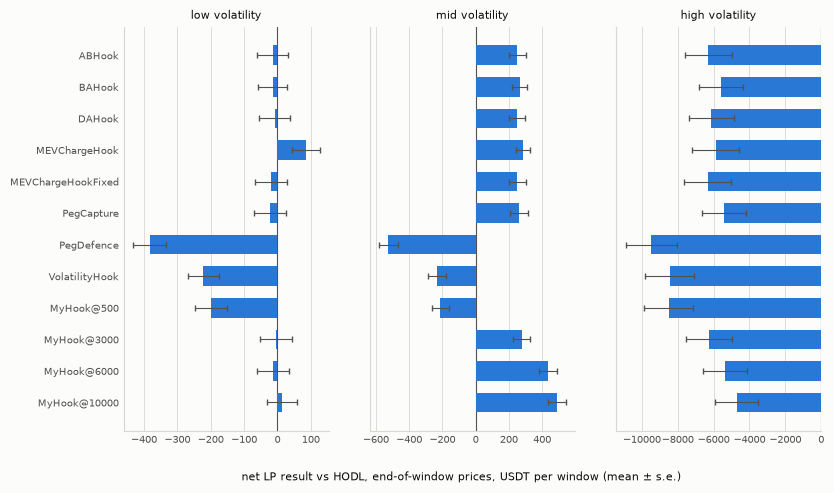

In [10]:
from IPython.display import Image, display


def draw(function, *args, name):
    """Write the PDF the paper uses, and a PNG so the notebook shows it."""
    function(*args, FIGURES / f"{name}.pdf")
    function(*args, FIGURES / f"{name}.png")
    display(Image(filename=str(FIGURES / f"{name}.png")))


draw(net_result_by_regime, frame, name="net_result_by_regime")

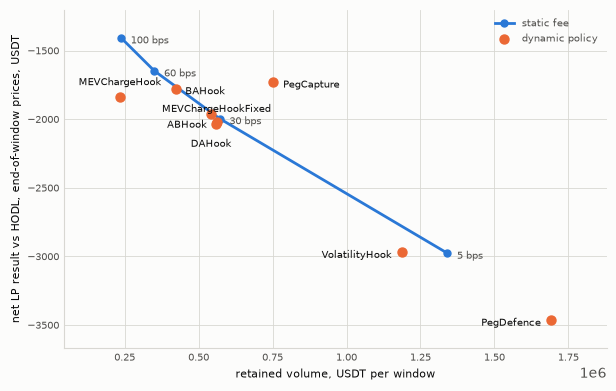

In [11]:
# Net result against retained volume. A policy wins by sitting above the static
# curve at the same volume -- the only reading that excludes "charge the maximum
# so nobody trades".
draw(frontier, frame, name="frontier")

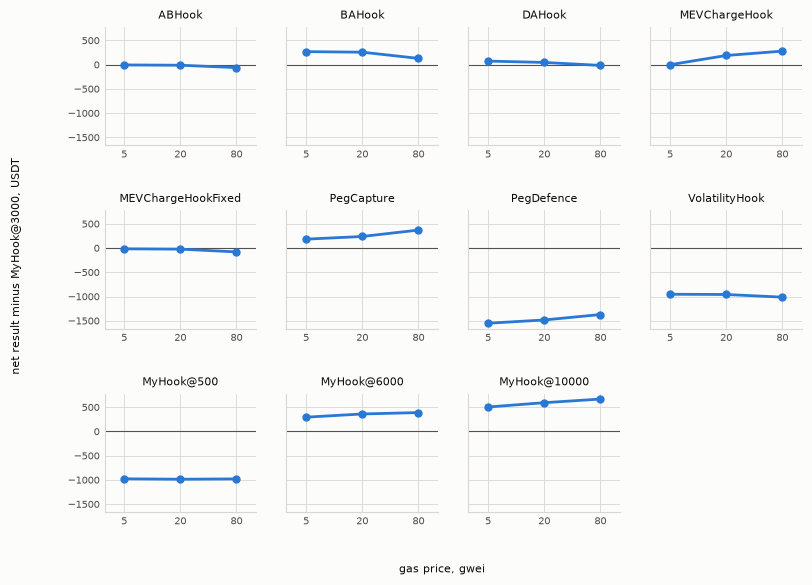

In [12]:
# Where each policy's advantage over static 30 bps crosses zero as gas rises.
draw(gas_breakeven, frame, name="gas_breakeven")

## The address mode was a control, and behaved like one

`persistent` vs `fresh` changes only who sends the swap. Identical results for
every policy but `MEVChargeHook` — which is the one policy that reads the
sender — is evidence the harness is not leaking state between cells.


In [13]:
modes = frame.pivot_table(
    index="policy", columns="address_mode", values="net_result", aggfunc="median"
)
modes["differs"] = (modes["persistent"] - modes["fresh"]).abs() > 1e-9
modes.round(2)

address_mode,fresh,persistent,differs
policy,,,
ABHook,0.0,0.0,False
BAHook,0.0,0.0,False
DAHook,0.0,0.0,False
MEVChargeHook,0.0,0.0,False
MEVChargeHookFixed,0.0,0.0,False
MyHook@10000,0.0,0.0,False
MyHook@3000,0.0,0.0,False
MyHook@500,0.0,0.0,False
MyHook@6000,0.0,0.0,False
